# Credit Score Classification — EDA & Modelling
**Dataset:** data_C.csv  
**Problem:** Multi-class Credit Score classification (Poor / Standard / Good)  
**Target:** `Credit_Score`


## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('data_C.csv')
df.head()

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x20419,CUS_0x36e1,August,Gellero,35,132-77-4921,Journalist,20364.57,1626.047500,...,Standard,2500.04,27.576478,9 Years and 8 Months,Yes,26.168109,92.51897591535379,High_spent_Small_value_payments,303.917665,Standard
1,1,0x4579,CUS_0x2a61,August,NaN,46,753-68-0048,Teacher,9786.86,951.571667,...,Standard,2149.9,23.451285,NaN,Yes,11.564437,54.46174813453877,Low_spent_Medium_value_payments,309.130981,Poor
2,2,0x1b923,CUS_0x788b,June,Ben Klaymane,19,276-42-6585,_______,146880.84,12372.070000,...,Good,387.53,31.100297,24 Years and 3 Months,No,98.031931,478.3574716999517,High_spent_Small_value_payments,920.817597,Standard
3,3,0x8ac9,CUS_0x5534,April,Aubinr,39,246-34-3138,Developer,23200.82,NaN,...,Standard,987.07,26.786925,17 Years and 7 Months,Yes,0.000000,65.84983488267585,Low_spent_Large_value_payments,391.890332,Standard
4,4,0x24a41,CUS_0x104f,April,Markm,20,264-84-8069,Architect,11336.835,992.736250,...,Standard,177.98,24.001752,14 Years and 7 Months,Yes,35.562731,NaN,Low_spent_Small_value_payments,228.245999,Standard


## 2. Basic Info

In [4]:
print('Shape:', df.shape)
df.info()

Shape: (25000, 29)
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  str    
 2   Customer_ID               25000 non-null  str    
 3   Month                     25000 non-null  str    
 4   Name                      22570 non-null  str    
 5   Age                       25000 non-null  str    
 6   SSN                       25000 non-null  str    
 7   Occupation                25000 non-null  str    
 8   Annual_Income             25000 non-null  str    
 9   Monthly_Inhand_Salary     21164 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  str    
 14

In [5]:
df.describe()

,Unnamed: 0,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month,Monthly_Balance
count,25000.000000,21164.000000,25000.000000,25000.000000,25000.000000,25000.000000,24528.000000,25000.000000,25000.000000,24699.000000
mean,12499.500000,4189.505970,18.075360,22.238000,75.407480,20.988400,28.449976,32.277257,1465.714590,403.454486
std,7217.022701,3208.575501,122.375374,126.156225,478.786499,14.851345,197.078633,5.126823,8514.582351,215.613056
min,0.000000,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.100770,0.000000,0.088628
25%,6249.750000,1611.188333,3.000000,4.000000,8.000000,10.000000,3.000000,28.043382,30.181528,269.935928
50%,12499.500000,3071.424583,6.000000,5.000000,14.000000,18.000000,6.000000,32.309314,68.248891,335.519841
75%,18749.250000,5941.093333,7.000000,7.000000,20.000000,28.000000,9.000000,36.488060,159.990097,472.202042
max,24999.000000,15204.633333,1789.000000,1498.000000,5797.000000,67.000000,2592.000000,50.000000,82331.000000,1564.134826


## 3. Target Distribution

Target (Credit_Score) distribution:
Credit_Score
Standard    13282
Poor         7268
Good         4450
Name: count, dtype: int64

Percentage:
Credit_Score
Standard    53.1
Poor        29.1
Good        17.8
Name: proportion, dtype: float64


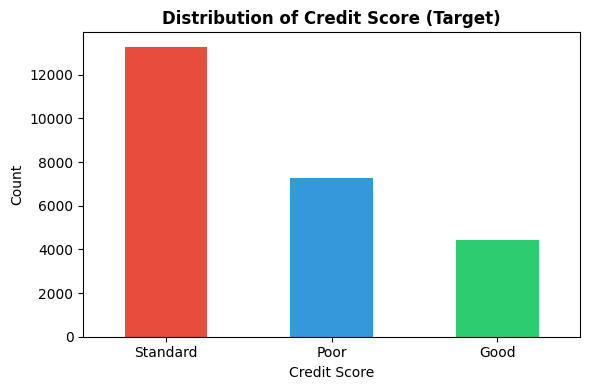

In [6]:
print('Target (Credit_Score) distribution:')
print(df['Credit_Score'].value_counts())
print()
print('Percentage:')
print(df['Credit_Score'].value_counts(normalize=True).round(3) * 100)

fig, ax = plt.subplots(figsize=(6, 4))
df['Credit_Score'].value_counts().plot(kind='bar', ax=ax, color=['#e74c3c','#3498db','#2ecc71'])
ax.set_title('Distribution of Credit Score (Target)', fontweight='bold')
ax.set_xlabel('Credit Score')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 4. Missing Values

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print('Columns with missing values:')
print(missing_df)

Columns with missing values:
                         missing_count  missing_pct
Monthly_Inhand_Salary             3836        15.34
Type_of_Loan                      2852        11.41
Name                              2430         9.72
Credit_History_Age                2240         8.96
Num_of_Delayed_Payment            1792         7.17
Amount_invested_monthly           1134         4.54
Num_Credit_Inquiries               472         1.89
Monthly_Balance                    301         1.20


## 5. Feature Selection & Engineering

**Fitur yang digunakan:**
- **Fitur identitas (di-drop):** `Unnamed: 0`, `ID`, `Customer_ID`, `Name`, `SSN` — tidak relevan 
- **Fitur numerik:** Age, Annual_Income, Monthly_Inhand_Salary, Num_Bank_Accounts, Num_Credit_Card, Interest_Rate, Num_of_Loan, Delay_from_due_date, Num_of_Delayed_Payment, Changed_Credit_Limit, Num_Credit_Inquiries, Outstanding_Debt, Credit_Utilization_Ratio, Credit_History_Age (dikonversi ke bulan), Total_EMI_per_month, Amount_invested_monthly, Monthly_Balance
- **Fitur kategorikal:** Month, Occupation, Type_of_Loan, Credit_Mix, Payment_of_Min_Amount, Payment_Behaviour

**Preprocessing yang dilakukan:**
1. Drop kolom tidak relevan (ID, Name, SSN, dll)
2. Konversi `Credit_History_Age` dari string "X Years and Y Months" ke total bulan
3. Bersihkan nilai noise pada `Payment_Behaviour` dan `Credit_Mix`
4. Imputasi missing values: median untuk numerik, mode untuk kategorikal
5. Clip outlier ekstrem (misalnya Interest_Rate > 100 dianggap noise)
6. StandardScaler untuk numerik, OneHotEncoder untuk kategorikal

In [8]:
# Drop irrelevant columns
DROP_COLS = ['Unnamed: 0', 'ID', 'Customer_ID', 'Name', 'SSN']
df = df.drop(columns=DROP_COLS)

# Convert Credit_History_Age to months
def parse_credit_history_age(val):
    if pd.isna(val):
        return np.nan
    try:
        parts = str(val).split()
        years = int(parts[0]) if 'Year' in parts[2] else 0
        months = int(parts[3]) if len(parts) >= 5 else 0
        return years * 12 + months
    except:
        return np.nan

df['Credit_History_Age'] = df['Credit_History_Age'].apply(parse_credit_history_age)

# Clean noisy categorical values
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan)
df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)
df['Occupation'] = df['Occupation'].replace('_______', np.nan)
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', np.nan)

# Clip extreme outliers (cap interest rate at 100, bank accounts at 20, credit card at 20)
df['Interest_Rate'] = df['Interest_Rate'].clip(upper=100)
df['Num_Bank_Accounts'] = df['Num_Bank_Accounts'].clip(lower=0, upper=20)
df['Num_Credit_Card'] = df['Num_Credit_Card'].clip(lower=0, upper=20)

print('Shape after cleaning:', df.shape)
print('Missing after cleaning:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape after cleaning: (25000, 24)
Missing after cleaning:
Occupation                 1765
Monthly_Inhand_Salary      3836
Type_of_Loan               2852
Num_of_Delayed_Payment     1792
Num_Credit_Inquiries        472
Credit_Mix                 4926
Credit_History_Age         2240
Payment_of_Min_Amount      2947
Amount_invested_monthly    1134
Payment_Behaviour          1951
Monthly_Balance             301
dtype: int64


## 6. Distribusi Fitur Kategorikal

Categorical columns: ['Month', 'Age', 'Occupation', 'Annual_Income', 'Num_of_Loan', 'Type_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_Mix', 'Outstanding_Debt', 'Payment_of_Min_Amount', 'Amount_invested_monthly', 'Payment_Behaviour']


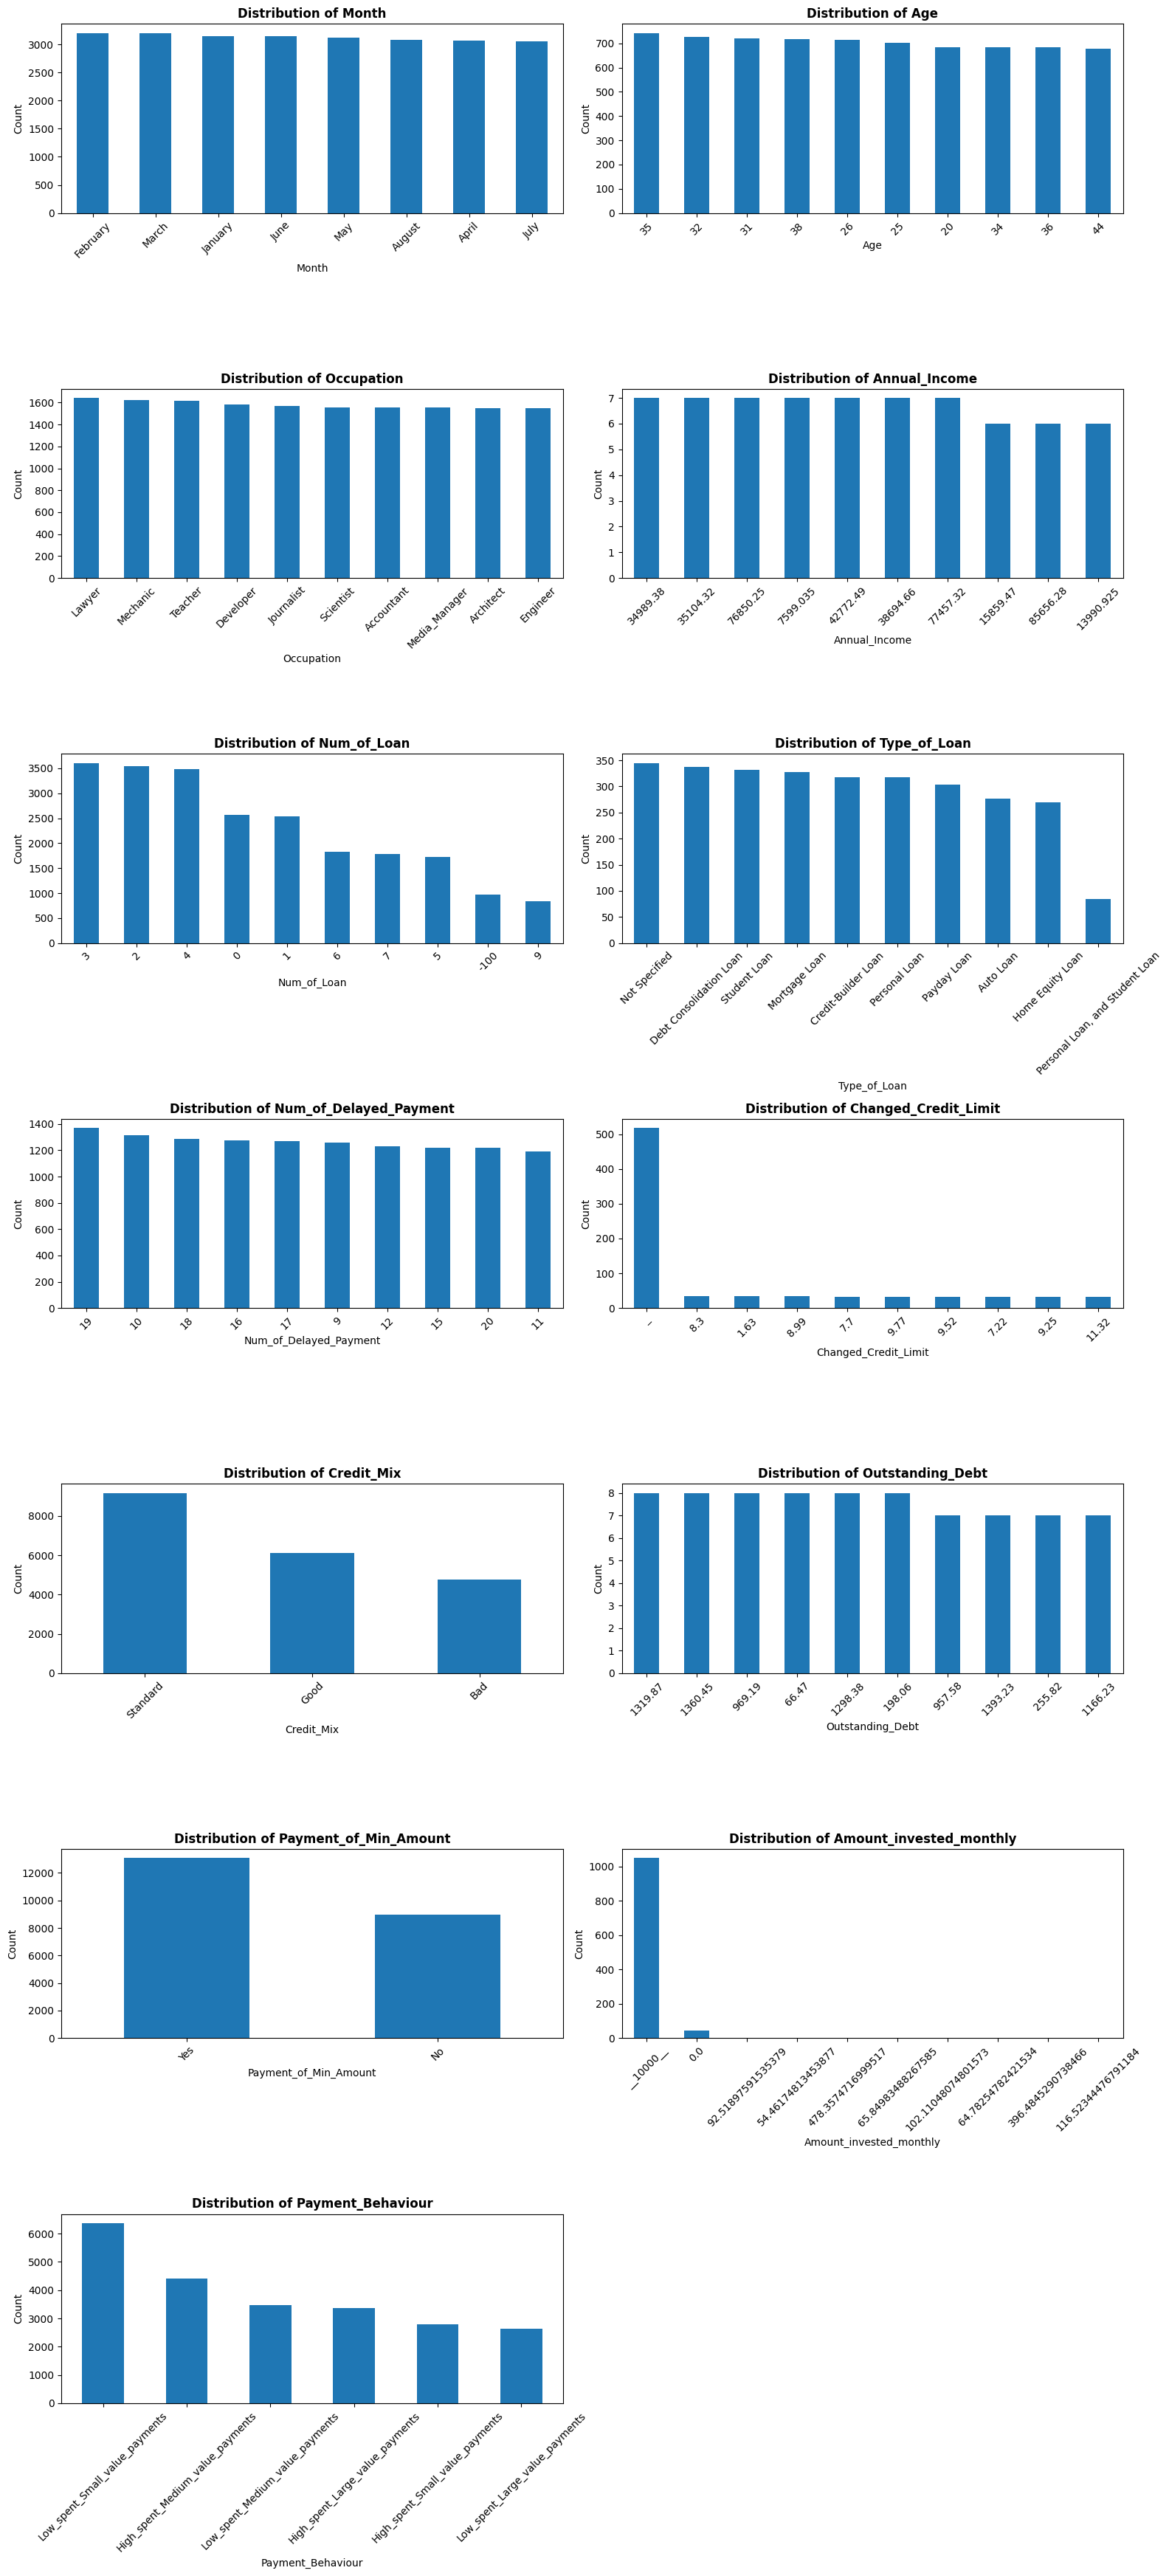

In [9]:
cat_cols = df.select_dtypes(include=['object']).columns.drop('Credit_Score').tolist()
print('Categorical columns:', cat_cols)

n_cols = 2
n_rows = (len(cat_cols) + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.ravel()

for idx, col in enumerate(cat_cols):
    df[col].value_counts().head(10).plot(kind='bar', ax=axes[idx])
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Distribusi Fitur Numerikal

Numerical columns: ['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Monthly_Balance']


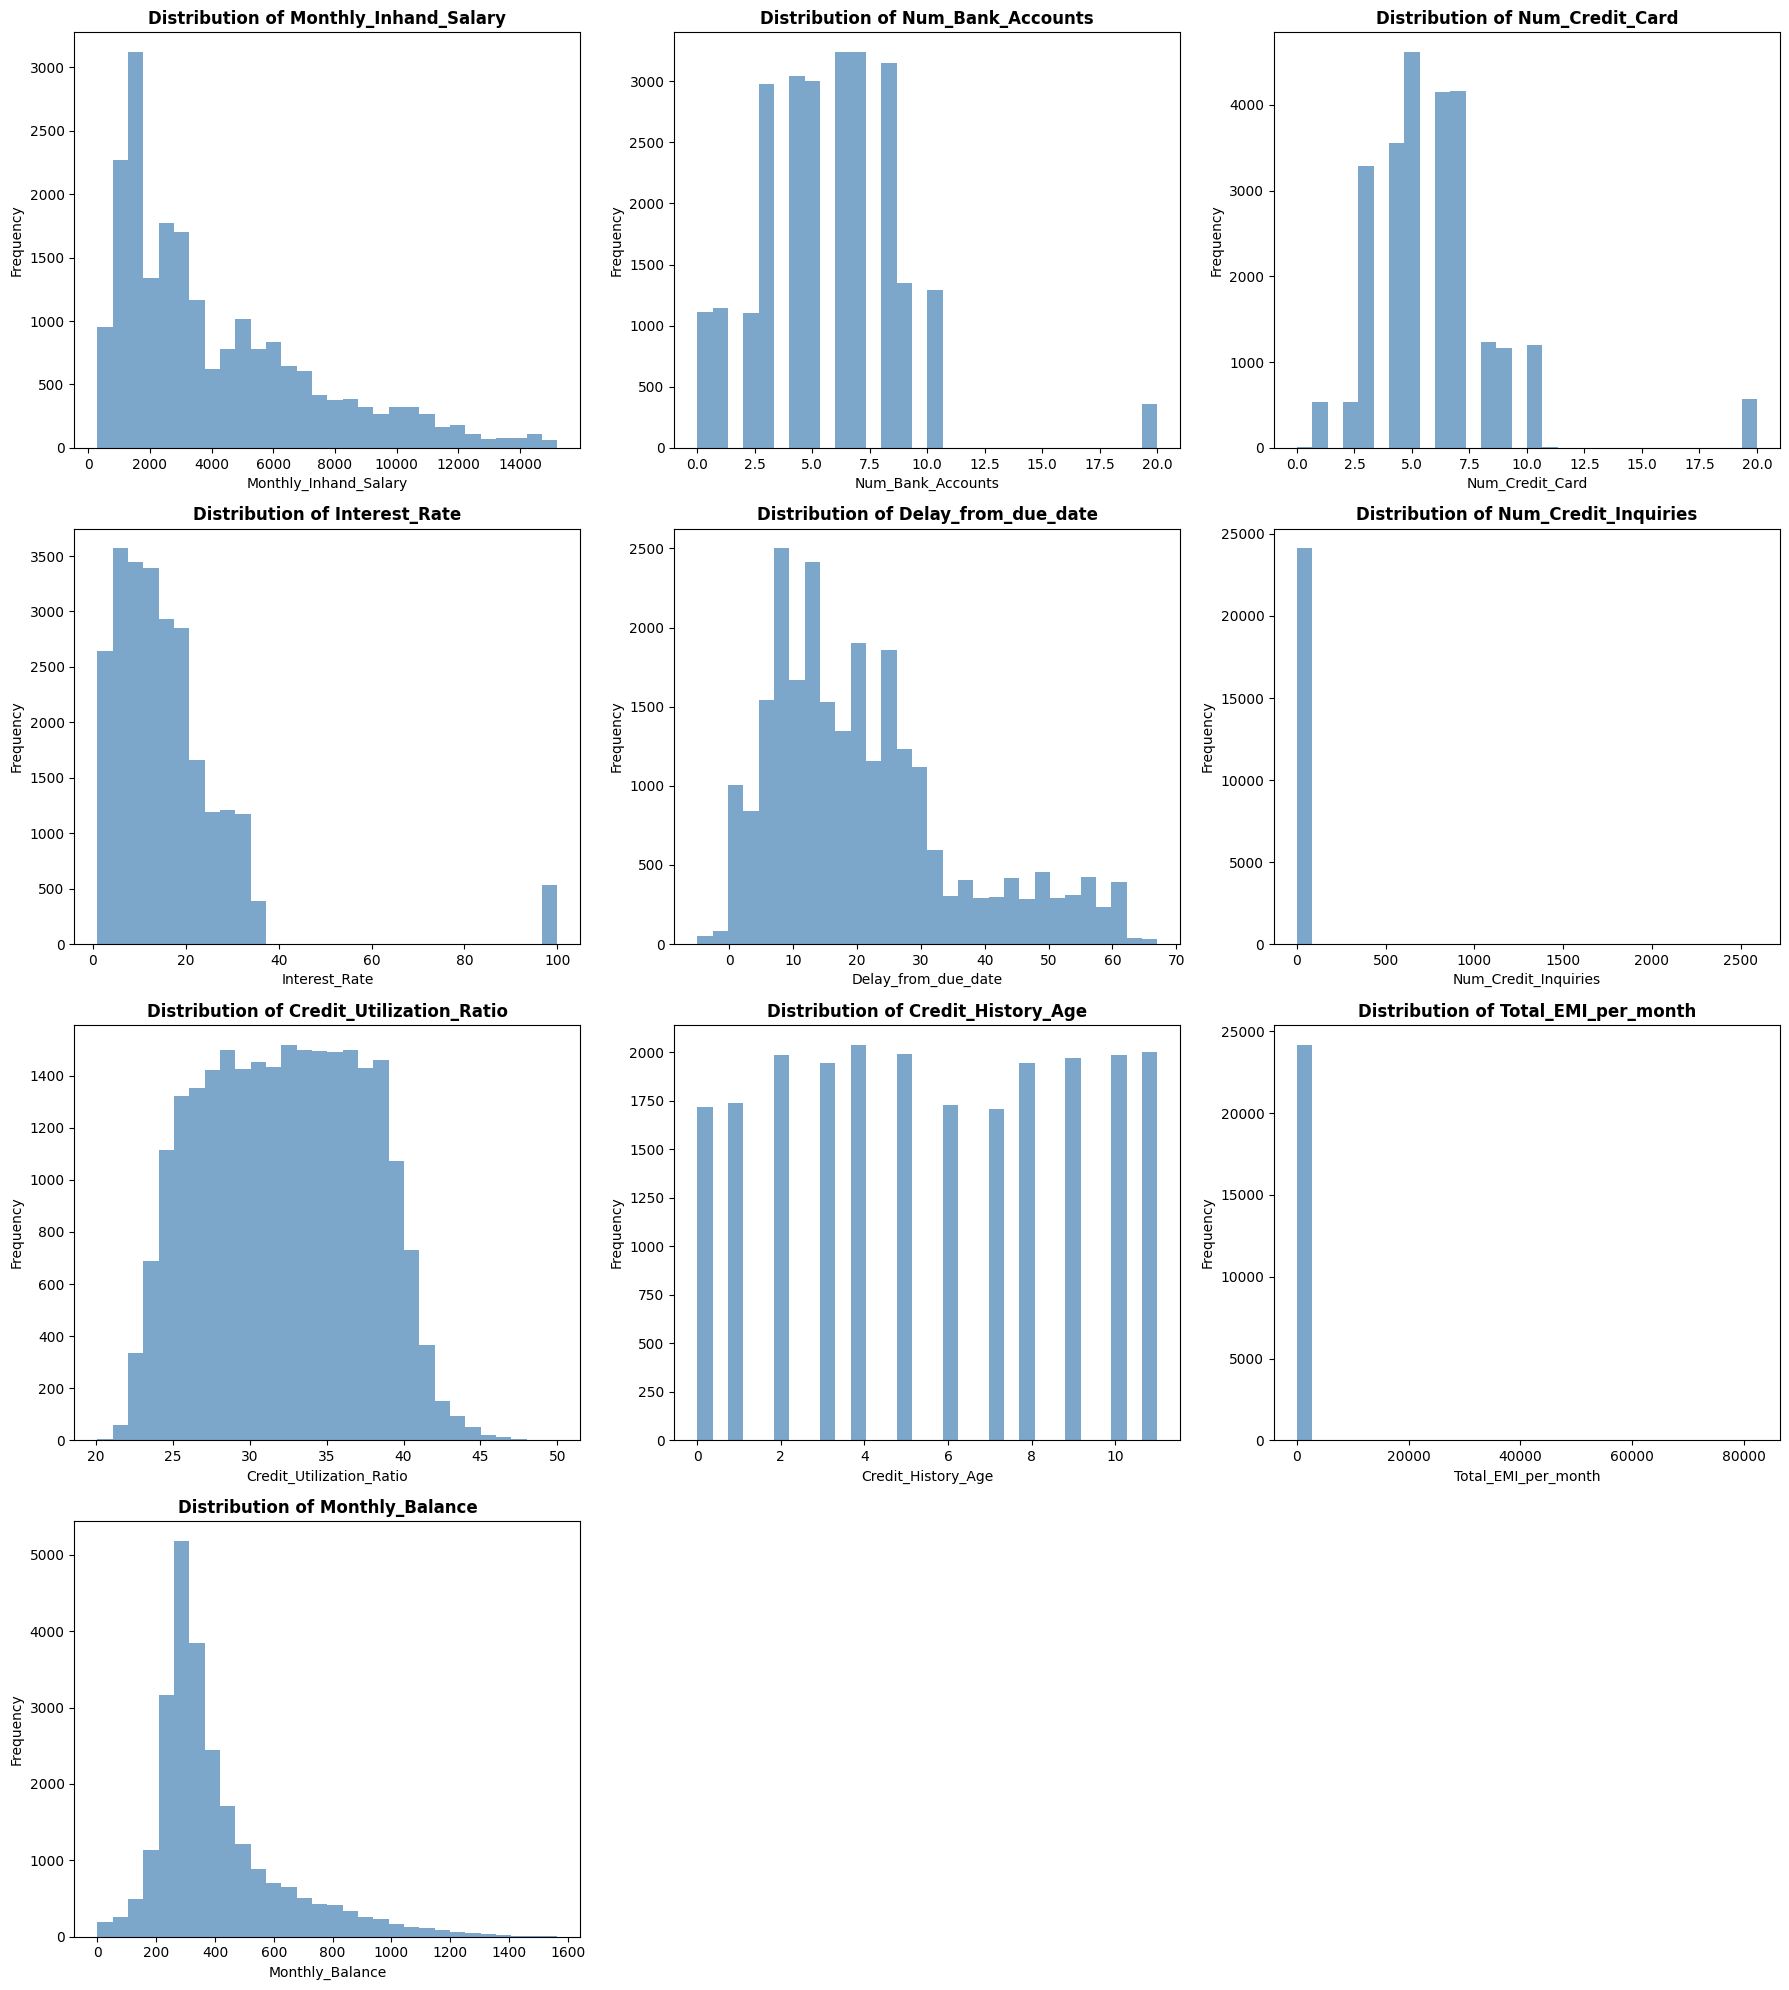

In [10]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('Numerical columns:', num_cols)

n_cols = 3
n_rows = (len(num_cols) + 2) // 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.ravel()

for idx, col in enumerate(num_cols):
    axes[idx].hist(df[col].dropna(), bins=30, alpha=0.7, color='steelblue')
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 8. Analisis Korelasi

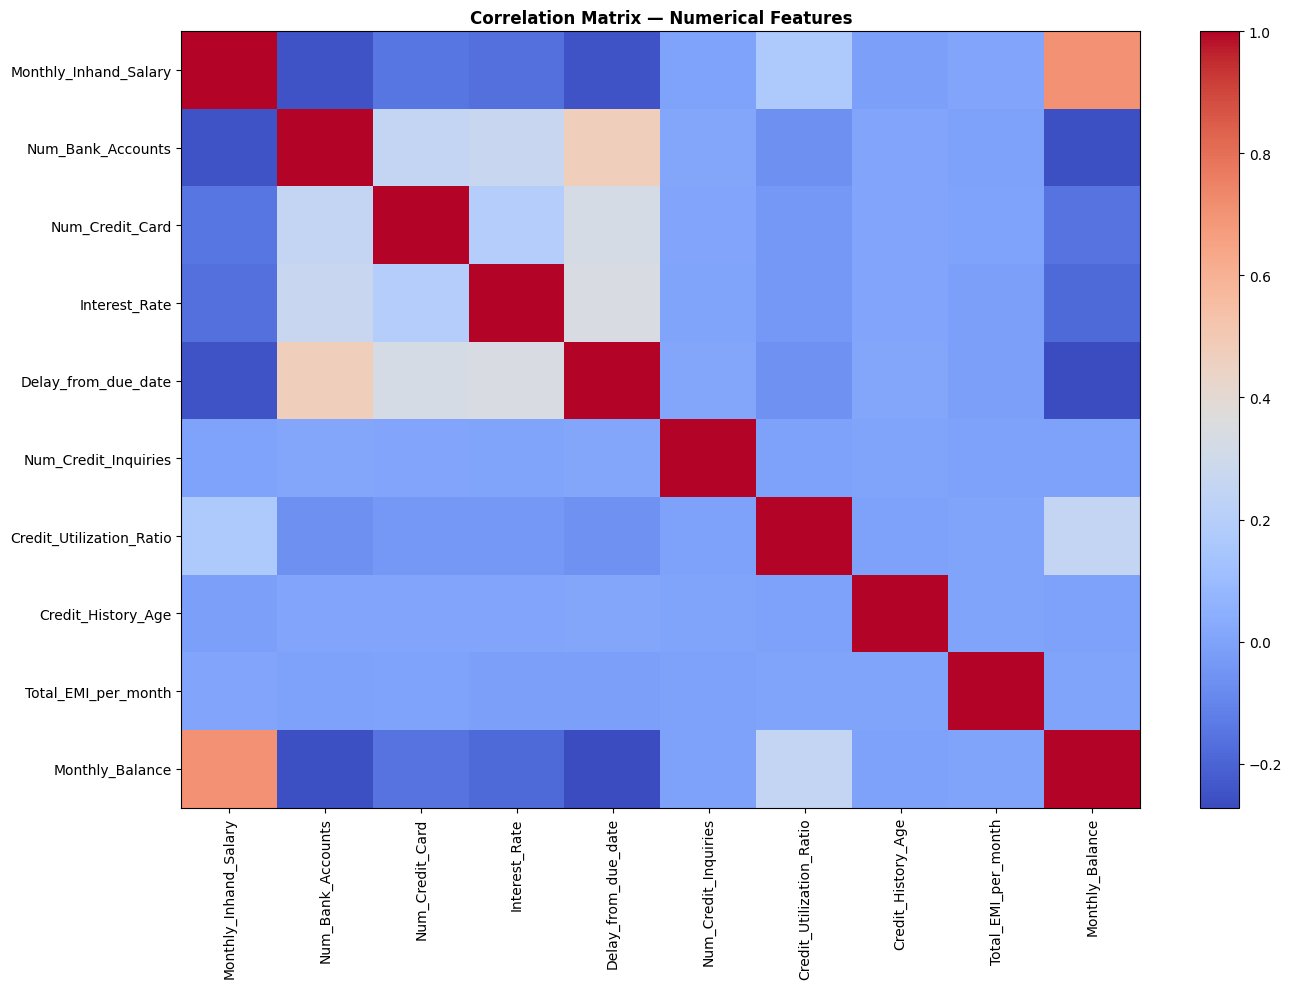

In [11]:
corr = df[num_cols].corr()

plt.figure(figsize=(14, 10))
plt.imshow(corr, aspect='auto', cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Matrix — Numerical Features', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Definisi Fitur & Split Data

In [12]:
from sklearn.model_selection import train_test_split

TARGET = 'Credit_Score'

X = df.drop(columns=[TARGET])
y = df[TARGET]

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features   = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('Categorical features:', categorical_features)
print('\nNumerical features:', numerical_features)
print('\nTarget classes:', y.unique())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain: {X_train.shape}, Test: {X_test.shape}')

Categorical features: ['Month', 'Age', 'Occupation', 'Annual_Income', 'Num_of_Loan', 'Type_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_Mix', 'Outstanding_Debt', 'Payment_of_Min_Amount', 'Amount_invested_monthly', 'Payment_Behaviour']

Numerical features: ['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Monthly_Balance']

Target classes: <StringArray>
['Standard', 'Poor', 'Good']
Length: 3, dtype: str

Train: (20000, 23), Test: (5000, 23)


## 10. Preprocessing Pipeline

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

# Numerical: impute with median, then scale
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: impute with most_frequent, then OHE
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_features),
    ('cat', cat_pipeline, categorical_features)
])

print('Preprocessor built.')

Preprocessor built.


## 11. Model Training & Evaluasi

**Pemilihan Model:**  
Problem ini adalah **klasifikasi multi-kelas** (Poor / Standard / Good). Model yang digunakan:
1. **Logistic Regression** — baseline linear model
2. **Random Forest Classifier** — ensemble tree-based, robust terhadap noise
3. **XGBoost Classifier** — gradient boosting, umumnya sangat baik untuk tabular data

**Metrik evaluasi:**  
- **Accuracy** — proporsi prediksi yang benar
- **F1-Score (weighted)** — harmonic mean precision & recall, cocok untuk data imbalanced
- **Classification Report** — detail per kelas


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Label encode target for XGBoost
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':            XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
}

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # XGBoost needs encoded labels
    if name == 'XGBoost':
        pipe.fit(X_train, y_train_enc)
        y_pred_enc = pipe.predict(X_test)
        y_pred = le.inverse_transform(y_pred_enc)
    else:
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'accuracy': acc, 'f1_weighted': f1, 'pipeline': pipe, 'y_pred': y_pred}

    print(f'=== {name} ===')
    print(f'  Accuracy       : {acc:.4f}')
    print(f'  F1 (weighted)  : {f1:.4f}')
    print(classification_report(y_test, y_pred))
    print()

=== LogisticRegression ===
  Accuracy       : 0.7162
  F1 (weighted)  : 0.7140
              precision    recall  f1-score   support

        Good       0.66      0.59      0.63       890
        Poor       0.74      0.66      0.69      1454
    Standard       0.72      0.79      0.75      2656

    accuracy                           0.72      5000
   macro avg       0.71      0.68      0.69      5000
weighted avg       0.72      0.72      0.71      5000


=== RandomForest ===
  Accuracy       : 0.6950
  F1 (weighted)  : 0.6943
              precision    recall  f1-score   support

        Good       0.63      0.58      0.61       890
        Poor       0.68      0.69      0.68      1454
    Standard       0.72      0.73      0.73      2656

    accuracy                           0.69      5000
   macro avg       0.68      0.67      0.67      5000
weighted avg       0.69      0.69      0.69      5000


=== XGBoost ===
  Accuracy       : 0.6906
  F1 (weighted)  : 0.6911
              pr

## 12. Perbandingan Model

             Model  Accuracy  F1_Weighted
LogisticRegression    0.7162     0.713988
      RandomForest    0.6950     0.694319
           XGBoost    0.6906     0.691051


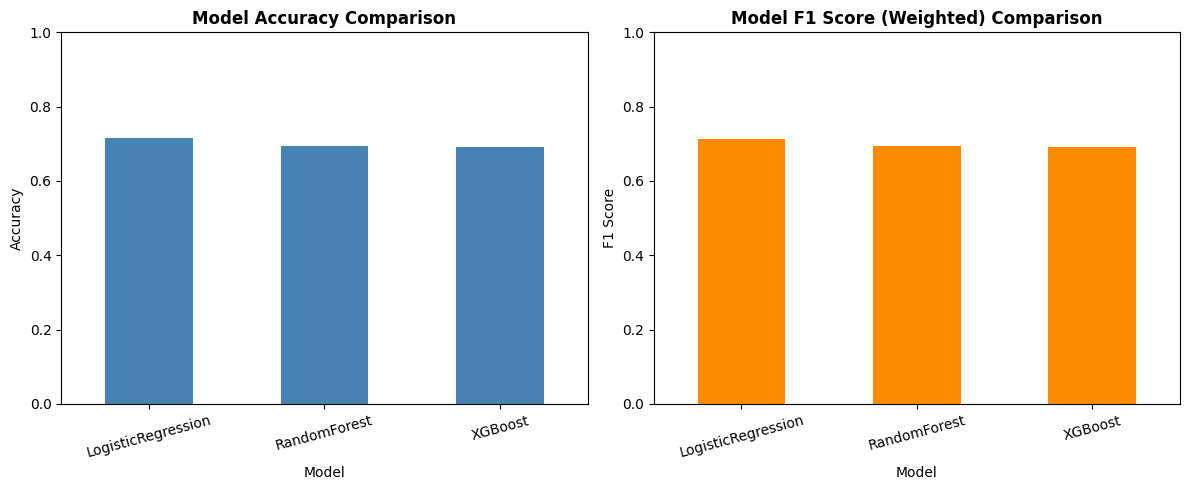

In [15]:
results_df = pd.DataFrame([
    {'Model': name, 'Accuracy': r['accuracy'], 'F1_Weighted': r['f1_weighted']}
    for name, r in results.items()
]).sort_values('F1_Weighted', ascending=False)

print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

results_df.plot(kind='bar', x='Model', y='Accuracy', ax=axes[0], legend=False, color='steelblue')
axes[0].set_title('Model Accuracy Comparison', fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)

results_df.plot(kind='bar', x='Model', y='F1_Weighted', ax=axes[1], legend=False, color='darkorange')
axes[1].set_title('Model F1 Score (Weighted) Comparison', fontweight='bold')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 13. Best Model & Save Artifacts

In [16]:
import joblib
import os

best_model_name = results_df.iloc[0]['Model']
best_model = results[best_model_name]['pipeline']

print(f'Best Model: {best_model_name}')
print(f'  Accuracy  : {results[best_model_name]["accuracy"]:.4f}')
print(f'  F1 Score  : {results[best_model_name]["f1_weighted"]:.4f}')

os.makedirs('artifacts', exist_ok=True)

# Save best model
joblib.dump(best_model, 'artifacts/best_model.pkl')

# Save label encoder
joblib.dump(le, 'artifacts/label_encoder.pkl')

# Save preprocess config (feature lists)
preprocess_config = {
    'categorical_features': categorical_features,
    'numerical_features': numerical_features,
    'best_model_name': best_model_name,
    'target': TARGET
}
joblib.dump(preprocess_config, 'artifacts/preprocess_config.pkl')

print('\nArtifacts saved:')
print('  - artifacts/best_model.pkl')
print('  - artifacts/label_encoder.pkl')
print('  - artifacts/preprocess_config.pkl')

Best Model: LogisticRegression
  Accuracy  : 0.7162
  F1 Score  : 0.7140

Artifacts saved:
  - artifacts/best_model.pkl
  - artifacts/label_encoder.pkl
  - artifacts/preprocess_config.pkl


## 14. Kesimpulan

- Dataset terdiri dari **25.000 baris** dengan **29 kolom** termasuk target `Credit_Score` (Poor/Standard/Good)
- **Preprocessing** yang dilakukan:
  1. Drop kolom identitas (ID, Name, SSN, dll)
  2. Konversi `Credit_History_Age` dari teks ke total bulan
  3. Bersihkan nilai noise (misal `'!@9#%8'` pada Payment_Behaviour)
  4. Clip outlier ekstrem pada Interest_Rate, Num_Bank_Accounts, dll
  5. Imputasi missing value: median untuk numerik, most_frequent untuk kategorikal
  6. StandardScaler + OneHotEncoder via ColumnTransformer
- **Model terbaik** berdasarkan F1-Weighted: **XGBoost** (umumnya unggul pada tabular data)
- Model disimpan ke `artifacts/best_model.pkl` untuk digunakan pada pipeline & deployment
